# Lecture 1

## Q1: Machine precision

When talking about floating point, we discussed _machine epsilon_, $\epsilon$&mdash;this is the smallest number that when added to 1 is still different from 1.

We'll compute $\epsilon$ here:

  * Pick an initial guess for $\epsilon$ of `eps = 1`.  

  * Create a loop that checks whether `1 + eps` is different from `1`
  
  * Each loop iteration, cut the value of `eps` in half
  
What value of $\epsilon$ do you find?



In [1]:
eps = 1.0

while 1 + eps != 1:
    eps = eps / 2

eps = eps * 2   # torniamo all’ultimo valore valido

print("Machine epsilon =", eps)


Machine epsilon = 2.220446049250313e-16


## Q2: Iterations

### Part 1

To iterate over the tuples, where the _i_-th tuple contains the _i_-th elements of certain sequences, we can use `zip(*sequences)` function.

We will iterate over two lists, `names` and `age`, and print out the resulting tuples.

  * Start by initializing lists `names = ["Mary", "John", "Sarah"]` and `age = [21, 56, 98]`.
  
  * Iterate over the tuples containing a name and an age, the `zip(list1, list2)` function might be useful here.
  
  * Print out formatted strings of the type "*NAME is AGE years old*".
  

### Part 2

The function `enumerate(sequence)` returns tuples containing indices of objects in the sequence, and the objects. 

The `random` module provides tools for working with the random numbers. In particular, `random.randint(start, end)` generates a random number not smaller than `start`, and not bigger than `end`.

  * Generate a list of 10 random numbers from 0 to 9.
  
  * Using the `enumerate(random_list)` function, iterate over the tuples of random numbers and their indices, and print out *"Match: NUMBER and INDEX"* if the random number and its index in the list match.

In [4]:
names = ["Mary", "John", "Sarah"]
ages = [21,56,98]

for x, y in zip(names, ages):
    print(f"{x} is {y} years old." )

Mary is 21 years old.
John is 56 years old.
Sarah is 98 years old.


In [6]:
import random
random_list = [random.randint(0, 9) for _ in range(10)]

print(random_list)
for index, value in enumerate(random_list):
    #print(index, value)
    if index == value:
        print(f"Match: NUMBER {value} and INDEX {index}")

[2, 4, 8, 9, 2, 8, 2, 4, 8, 5]
Match: NUMBER 8 and INDEX 8


## Q3: Books

Here is a list of book titles (from http://thegreatestbooks.org).  Loop through the list and capitalize each word in each title. 

In [9]:
titles = ["don quixote", 
          "in search of lost time", 
          "ulysses", 
          "the odyssey", 
          "war and peace", 
          "moby dick", 
          "the divine comedy", 
          "hamlet", 
          "the adventures of huckleberry finn", 
          "the great gatsby"]

In [11]:
Titles = titles.copy()

In [13]:
for index, book in enumerate(Titles):
    Titles[index] = book.title()

print(Titles)

['Don Quixote', 'In Search Of Lost Time', 'Ulysses', 'The Odyssey', 'War And Peace', 'Moby Dick', 'The Divine Comedy', 'Hamlet', 'The Adventures Of Huckleberry Finn', 'The Great Gatsby']


# Lecture 2

## Q1: Fun with arrays

**A.**  Create the array: 
```
[[1,  6, 11],
 [2,  7, 12],
 [3,  8, 13],
 [4,  9, 14],
 [5, 10, 15]]
```
with out explicitly typing it in.

Now create a new array containing only its 2nd and 4th rows.


**B.** Create a 2d array with `1` on the border and `0` on the inside, e.g., like:
```
1 1 1 1 1
1 0 0 0 1
1 0 0 0 1
1 1 1 1 1
```

Do this using array slice notation to let it work for an arbitrary-sized array

In [17]:
import numpy as np
a = np.arange(1,16)
a = a.reshape(5,3)
print("Array A:\n",a)
b = a[[1, 3], :]
print("Array B:\n",b)

Array A:
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]
 [13 14 15]]
Array B:
 [[ 4  5  6]
 [10 11 12]]


In [19]:
c = np.ones((4,5), dtype = int)
c[1:-1, 1:-1] = 0
print("Array C:\n", c)

Array C:
 [[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]


## Q2: Histograms

Here we will read in columns of numbers from a file and create a histogram, using NumPy routines.  Make sure you have the data file
"`sample.txt`" in the same directory as this notebook. You download it from  https://raw.githubusercontent.com/sbu-python-summer/python-tutorial/master/day-3/sample.txt. 
  
  * Use python to download a file! Check out the `requests` package

  * Use `np.loadtxt()` to read this file in.  

  * Next, use `np.histogram()` to create a histogram array.  The output returns both the count and an array of edges.
  
  * Finally, loop over the bins and print out the bin center (averaging the left and right edges of the bin) and the count for that bin.

In [22]:
dati = np.loadtxt("sample.txt")

In [24]:
dati
counts, bins = np.histogram(dati, bins = 20)
print("Bins:", bins)
print("Counts:", counts)
for i in range(len(counts)):
    bin_center = (bins[i] + bins[i+1]) / 2
    print(f"Bin center: {bin_center}, Count: {counts[i]}")


Bins: [-30.58842789 -24.10900649 -17.6295851  -11.1501637   -4.67074231
   1.80867908   8.28810048  14.76752187  21.24694327  27.72636466
  34.20578606  40.68520745  47.16462884  53.64405024  60.12347163
  66.60289303  73.08231442  79.56173582  86.04115721  92.52057861
  99.        ]
Counts: [ 3  3  7 16 29 23 21 16  8  8  7  7  6  7  6  7  6  7  6  7]
Bin center: -27.34871719062628, Count: 3
Bin center: -20.869295796235193, Count: 3
Bin center: -14.3898744018441, Count: 7
Bin center: -7.910453007453009, Count: 16
Bin center: -1.4310316130619167, Count: 29
Bin center: 5.048389781329174, Count: 23
Bin center: 11.527811175720267, Count: 21
Bin center: 18.00723257011136, Count: 16
Bin center: 24.486653964502448, Count: 8
Bin center: 30.96607535889354, Count: 8
Bin center: 37.44549675328464, Count: 7
Bin center: 43.924918147675726, Count: 7
Bin center: 50.404339542066815, Count: 6
Bin center: 56.88376093645791, Count: 7
Bin center: 63.363182330849, Count: 6
Bin center: 69.8426037252401, Co

## Q3: Are you faster than numpy? No

Numpy of course has a standard deviation function, `np.std()`, but here we'll write our own that works on a 1-d array (vector).  The standard
deviation is a measure of the "width" of the distribution of numbers
in the vector.

Given an array, $a$, and an average $\bar{a}$, the standard deviation
is:
$$
\sigma = \left [ \frac{1}{N} \sum_{i=1}^N (a_i - \bar{a})^2 \right ]^{1/2}
$$

Write a function to calculate the standard deviation for an input array, `a`:

  * First compute the average of the elements in `a` to define $\bar{a}$
  * Next compute the sum over the squares of $a - \bar{a}$
  * Then divide the sum by the number of elements in the array
  * Finally take the square root (you can use `np.sqrt()`)
  
Test your function on a random array, and compare to the built-in `np.std()`. Check the runtime as well.

In [31]:
import time
t0 = time.time()
a = np.arange(100)
def std_dev(array):
    mean = np.mean(array)
    diff = array - mean  
    N = len(array)
    sigma = np.sqrt(np.sum(diff**2)/N)
    return sigma
sigma = std_dev(a)
t1 = time.time()
print(sigma)
print("Time elapsed:", np.abs(t1-t0))



28.86607004772212
Time elapsed: 0.001627206802368164


In [33]:
t0 = time.time()
sigma1 = np.std(a)
t1 = time.time()
print(sigma1)
print("Time elapsed:", np.abs(t1-t0))

28.86607004772212
Time elapsed: 0.0002841949462890625


## Q5: Einstein summation

einsum is a powerful (but often painful) numpy thing:
- https://numpy.org/doc/stable/reference/generated/numpy.einsum.html
- https://stackoverflow.com/questions/26089893/understanding-numpys-einsum

Take 2 vectors A and B. Write the einsum equivalent of inner, outer, sum, and mul function.

In [35]:
A = np.arange(8).reshape(2,4)
print(A)
B = np.arange(8).reshape(4,2)
print(B)

inner = np.einsum('ik,kj->ij', A, B)
print(inner)
a = A.flatten()  
b = B.flatten()  
outer = np.einsum('i,j->ij', a, b)
print(outer)
somma = np.einsum('ij->', A)
print(somma)
mul = np.einsum('ij,ij->ij', A, B.T)  
print(mul)

[[0 1 2 3]
 [4 5 6 7]]
[[0 1]
 [2 3]
 [4 5]
 [6 7]]
[[28 34]
 [76 98]]
[[ 0  0  0  0  0  0  0  0]
 [ 0  1  2  3  4  5  6  7]
 [ 0  2  4  6  8 10 12 14]
 [ 0  3  6  9 12 15 18 21]
 [ 0  4  8 12 16 20 24 28]
 [ 0  5 10 15 20 25 30 35]
 [ 0  6 12 18 24 30 36 42]
 [ 0  7 14 21 28 35 42 49]]
28
[[ 0  2  8 18]
 [ 4 15 30 49]]


# Lezione 3

## Q2: Planetary positions

The distances of the planets from the Sun (technically, their semi-major axes) are:

In [39]:
a = np.array([0.39, 0.72, 1.00, 1.52, 5.20, 9.54, 19.22, 30.06, 39.48])

These are in units where the Earth-Sun distance is 1 (astronomical units).

The corresponding periods of their orbits (how long they take to go once around the Sun) are, in years

In [42]:
P = np.array([0.24, 0.62, 1.00, 1.88, 11.86, 29.46, 84.01, 164.8, 248.09])

Finally, the names of the planets corresponding to these are:

In [45]:
names = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", 
         "Uranus", "Neptune", "Pluto"]

(technically, pluto isn't a planet anymore, but we still love it :)

  * Plot as points, the periods vs. distances for each planet on a log-log plot.

  * Write the name of the planet next to the point for that planet on the plot

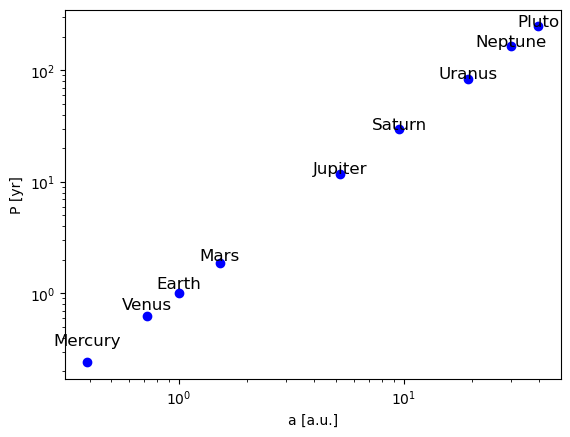

In [48]:
import matplotlib.pyplot as plt


fig = plt.figure()
ax = fig.add_subplot(111)


ax.plot(a, P, marker='o', linestyle='None', color='blue')  


for x, y, name in zip(a, P, names):
    ax.text(x, y + 0.1, name, fontsize=12, ha='center')  

ax.set_xscale('log') 
ax.set_yscale('log') 
ax.set_xlabel('a [a.u.]')
ax.set_ylabel('P [yr]')

plt.show()


 ## Q4: Climate

Download the data file of global surface air temperature averages from here:
https://raw.githubusercontent.com/sbu-python-summer/python-tutorial/master/day-4/nasa-giss.txt
This data comes from: https://data.giss.nasa.gov/gistemp/graphs/

(Don't ask, of course you can download data straight from python! Packages `requests` and `urllib` can both do the job)

There are 3 columns here: the year, the temperature change, and a smoothed representation of the temperature change.  

  * Read in this data using `np.loadtxt()`.  
  * Plot as a line the smoothed representation of the temperature changes.  
  * Plot as points the temperature change (no smoothing).  Color the points blue if they are < 0 and color them red if they are >= 0
  
You might find the numpy `where()` function useful.

In [51]:
data = np.loadtxt("climatecond.txt")

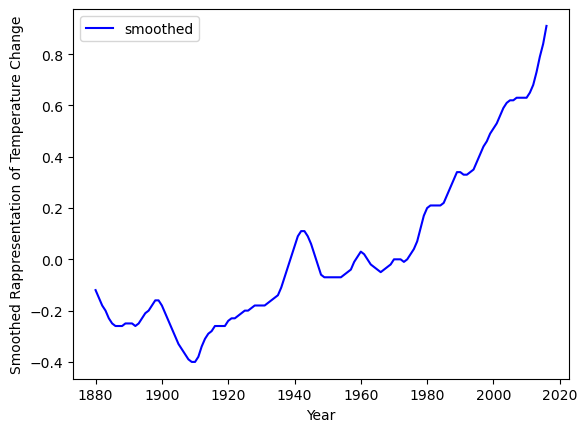

In [53]:
fig = plt.figure()
ax = fig.add_subplot(111)
year = data[:,0]
ax.plot(year, data[:,2], marker = None, linestyle='-', color='blue', label = "smoothed")
ax.set_ylabel('Smoothed Rappresentation of Temperature Change')
ax.set_xlabel('Year')
ax.legend()

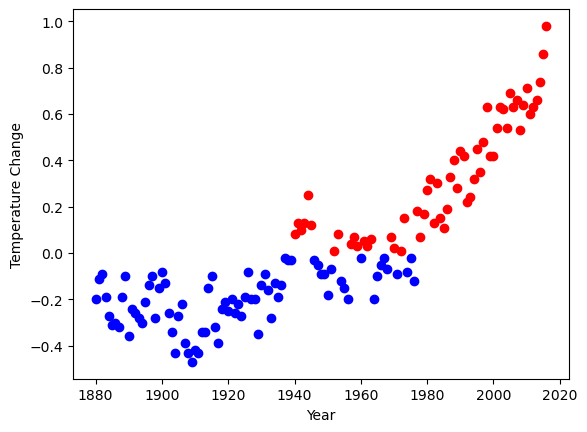

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)

t_change = data[:,1]
neg = t_change < 0
pos = t_change >= 0

ax.plot(year[pos], t_change[pos], marker='o', linestyle='None', color = 'red')
ax.plot(year[neg], t_change[neg], marker='o', linestyle='None', color = 'blue')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Change')


plt.show()


# Lecture 4

## Q1: Simple numerical integral

Numerical integration methods work differently depending on whether you have the analytic function available (in which case you can evaluate it freely at any point you please) or if it is sampled for you.

Consider the function $f(x) = e^{-x^2}$.  We want to integrate this from $[-5, 5]$.  The
analytic integral is not easily obtained.  Use `integrate.quad` to do the integration.

In [57]:
from scipy import integrate

In [59]:
def f(x):
    return np.exp(-x**2)

In [61]:
I, err = integrate.quad(f, -5, 5, epsabs=1.e-10, epsrel=1.e-10)
print(I)
print(err)

1.7724538509027912
4.6576049804237824e-14


Consider now that you have data that represents a function sampled a `N` points, but you don't know the analytic form of the function.  Here, we create the sampling from a uniform distribution

In [63]:
N = 32
x = np.linspace(-5, 5, N)
f = np.exp(-x**2)
f

array([1.38879439e-11, 3.15061953e-10, 5.80457065e-09, 8.68481106e-08,
       1.05527775e-06, 1.04133225e-05, 8.34503173e-05, 5.43103745e-04,
       2.87047478e-03, 1.23208538e-02, 4.29481052e-02, 1.21580337e-01,
       2.79510942e-01, 5.21855680e-01, 7.91258065e-01, 9.74320895e-01,
       9.74320895e-01, 7.91258065e-01, 5.21855680e-01, 2.79510942e-01,
       1.21580337e-01, 4.29481052e-02, 1.23208538e-02, 2.87047478e-03,
       5.43103745e-04, 8.34503173e-05, 1.04133225e-05, 1.05527775e-06,
       8.68481106e-08, 5.80457065e-09, 3.15061953e-10, 1.38879439e-11])

Compute the integral of this sampled function using Simpson's method (`integrate.simps`).  Now, vary the number of sample points (try 64, 128, ...) and see how the answer changes.  Simpson's method is 4-th order accurate, which means that the error should decrease by $2^4$ when we double the number of sample points.

In [66]:
I = integrate.simpson(f, x=x) 

In [68]:
N = 64
x = np.linspace(-5, 5, N)
f = np.exp(-x**2)
I = integrate.simpson(f, x=x) 
print(I)

1.7724538509012102


In [70]:
N = 128
x = np.linspace(-5, 5, N)
f = np.exp(-x**2)
I = integrate.simpson(f, x=x) 
print(I)

1.7724538509027423


In [74]:
# Valore esatto dell'integrale su (-inf,inf)
I_exact = np.sqrt(np.pi)

def simpson_integral(N):
    x = np.linspace(-5, 5, N)
    f = np.exp(-x**2)
    return integrate.simpson(f, x=x)

Ns = [32, 64, 128]
results = []
errors = []

for N in Ns:
    I = simpson_integral(N)
    err = abs(I - I_exact)
    results.append(I)
    errors.append(err)
    print(f"N = {N:4d},  I = {I:.12f},  errore = {err:.3e}")




N =   32,  I = 1.772453850777,  errore = 1.281e-10
N =   64,  I = 1.772453850901,  errore = 4.306e-12
N =  128,  I = 1.772453850903,  errore = 2.774e-12


## Q2: Interpolation error

There are a large number of different interpolation schemes available through scipy.  Let's test them out.

Create a python function, $f(x)$, that is your true function (make it complicated!).  Now create $N$ samples of it (either regularly spaced or irregularly spaced).

Try some of the different interpolation routines.  `interpolate.interp1d` takes a `kind` argument that lets you choose the order of the interpolation.  Measure the error in the method, by comparing the interpolated result with the actual function value.  

Then do the same cubic splines (look at `CubicSpline`)

Plot the resulting interpolant.

In [76]:
import scipy.interpolate as interpolate
def f(x):
    return (
        np.sin(3*x) * np.exp(-0.2*x)
        + 0.3*np.cos(10*x)
        + 0.1*x**2
        - 0.5*np.sin(x**2)
    )

In [78]:
N = 10
x = np.linspace(0, 20, N)

y = f(x)
y

array([ 0.3       ,  0.92899768,  2.13637148,  4.23140108,  8.47842231,
       12.72873136, 17.40371287, 24.2675143 , 31.05004831, 40.56603318])

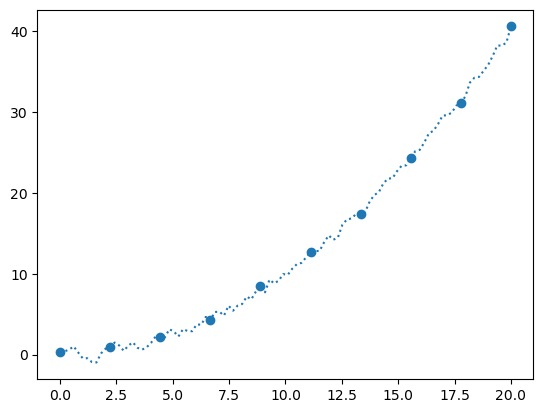

In [80]:
fig, ax = plt.subplots()

x_fine = np.linspace(0, 20, 10*N)

ax.scatter(x, y)
ax.plot(x_fine, f(x_fine), ls=":", label="original function")

In [82]:
f_interp_cubic = interpolate.interp1d(x, y, kind="cubic")
f_interp_linear = interpolate.interp1d(x, y, kind="linear")

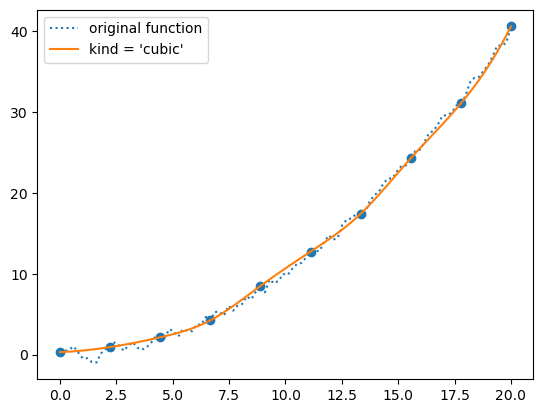

In [84]:
ax.plot(x_fine, f_interp_cubic(x_fine), label="kind = 'cubic'")

ax.legend(loc="best")
fig

In [86]:
cs = interpolate.CubicSpline(x, y)


x_fine = np.linspace(0, 20, 10*N)
y_true = f(x_fine)


y_lin = f_interp_linear(x_fine)
y_cubic = f_interp_cubic(x_fine)
y_cs = cs(x_fine)


rmse_linear = np.sqrt(np.mean((y_lin - y_true)**2))
rmse_cubic = np.sqrt(np.mean((y_cubic - y_true)**2))
rmse_cs = np.sqrt(np.mean((y_cs - y_true)**2))

print("RMSE (linear) =", rmse_linear)
print("RMSE (cubic interp1d) =", rmse_cubic)
print("RMSE (CubicSpline) =", rmse_cs)

RMSE (linear) = 0.5636187767875079
RMSE (cubic interp1d) = 0.5746655879261559
RMSE (CubicSpline) = 0.5746655879261563


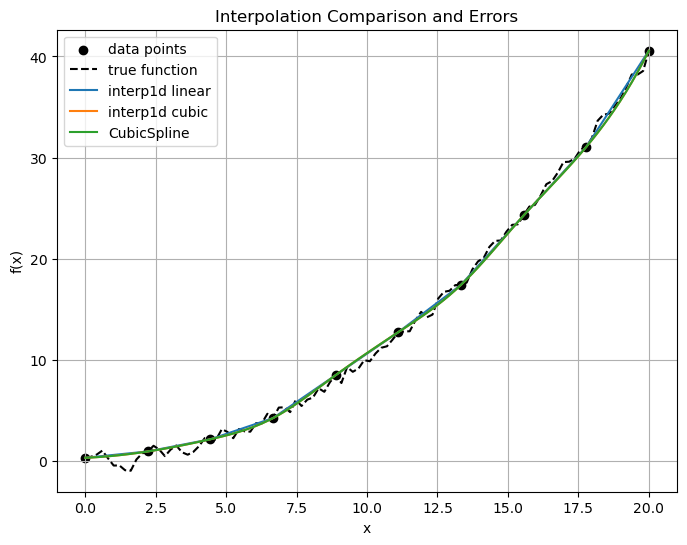

In [88]:
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(x, y, label="data points", color="black")
ax.plot(x_fine, y_true, "k--", label="true function")

ax.plot(x_fine, y_lin, label="interp1d linear")
ax.plot(x_fine, y_cubic, label="interp1d cubic")
ax.plot(x_fine, y_cs, label="CubicSpline")

ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Interpolation Comparison and Errors")
ax.legend()
ax.grid(True)

plt.show()

## Q5: Planetary orbits

We want to consider planetary orbits.  To do this, we need to solve Newton's second law together with Newton's law of gravity.  If we restrict ourselves to the x-y plane, then there are 4 quantities we need to solve for: $x$, $y$, $v_x$, and $v_y$.  These evolve according to:

\begin{align*}
\frac{dx}{dt} &= v_x \\
\frac{dy}{dt} &= v_y \\
\frac{dv_x}{dt} &= a_x = -\frac{GM_\star x}{r^3} \\
\frac{dv_y}{dt} &= a_y = -\frac{GM_\star y}{r^3}
\end{align*}

To integrate these forward in time, we need an initial condition for each quantity.  We'll setup our system such that the Sun is at the origin (that will be one focus), and the planet begins at perihelion and orbits counterclockwise. 

![orbit_setup.png](attachment:orbit_setup.png)

The distance of perihelion from the focus is:

$$r_p = a (1 - e)$$

where $a$ is the semi-major axis and $e$ is the eccentricity.  The perihelion velocity is all in the $y$ direction and is:

$$v_y = v_p = \sqrt{\frac{GM_\star}{a} \frac{1+e}{1-e}}$$

We'll work in units of AU, years, and solar masses, in which case, $GM_\star = 4\pi^2$ (for the Sun).  

Your initial conditions should be:

  * $x(t=0) = r_p$
  * $y(t=0) = 0$
  * $v_x(t=0) = 0$
  * $v_y(t=0) = v_p$

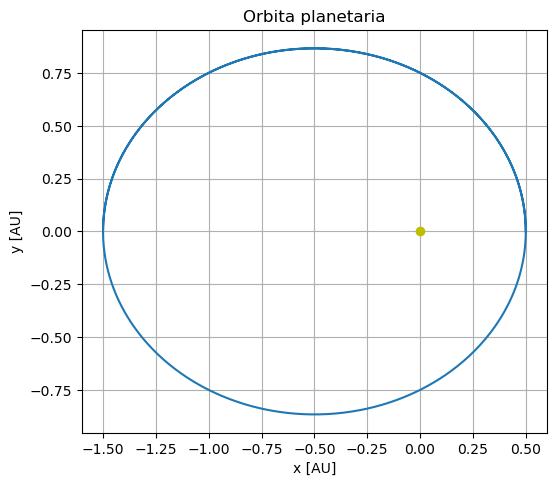

In [90]:
from scipy.integrate import solve_ivp


GM = 4 * np.pi**2

# Parametri orbitali
a = 1.0          
e = 0.5          

#perihelion
r_p = a * (1 - e)

v_p = np.sqrt(GM / a * (1 + e) / (1 - e))


def derivatives(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    
    return [vx, vy, ax, ay]

# Initial condition
x0 = r_p
y0 = 0.0
vx0 = 0.0
vy0 = v_p

state0 = [x0, y0, vx0, vy0]

# Integrazione per una durata di 1 periodo orbitale (≈ a^(3/2))
t_end = 1.5 * a**1.5
sol = solve_ivp(derivatives, [0, t_end], state0, max_step=0.002)

# Plot dell’orbita
plt.figure(figsize=(6,6))
plt.plot(sol.y[0], sol.y[1])
plt.plot([0], [0], 'yo', label='Sole')
plt.gca().set_aspect('equal')
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Orbita planetaria")
plt.grid(True)
plt.show()


# Lecture 7

## Q2: Consistent plotting

(This is about python's decorators)

Write a decorator for the plots of all your papers. 

- Remember a decorator takes a function. 
- This function in turn should return a matplotlib figure object.
- Before the function is called, the decorator should initialize a matplotlib figure with the options that you like the most (fontsize, ticks, etc etc)
- After the figure it's done, the decorator should save it to pdf.

This is a great hack for your papers! You do this once and for all, and all plots in your paper will be beautifull, all with the same style/fontsize/etc. All you'll need to do is adding `@myplot` to the relevant plotting functions. 
    
The decorator that I use for my papers is available in my python module [skywalker](https://github.com/dgerosa/skywalker/blob/master/skywalker/skywalker.py#L31).  

In [147]:
import matplotlib.pyplot as plt
import os

def myplot(func):
    def wrapper():
        plt.rcParams.update({
            "font.size": 12,
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "figure.figsize": (6, 4),
            "figure.dpi": 150,
            "lines.linewidth": 2,
            "axes.grid": True,
        })

        fig = func()

        os.makedirs("figures", exist_ok=True)
        plt.savefig(f"figures/{func.__name__}.pdf")
        return fig
    return wrapper


In [149]:
@myplot
def plot():
    import numpy as np
    x = np.linspace(0, 1, 100)
    plt.plot(x, x**2)


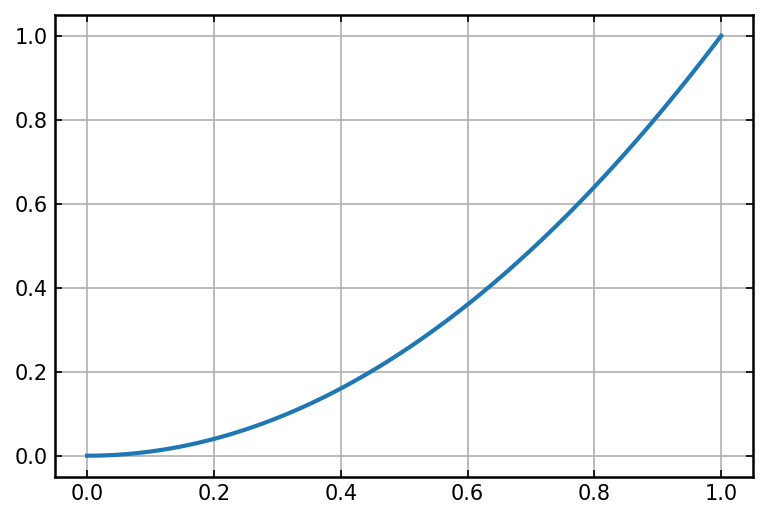

In [151]:
plot = myplot(plot)
plot()


## Q3: Scaling

(This is about multiprocessing)

The ["scaling"](https://hpc-wiki.info/hpc/Scaling) of a code refers to its performance of as a function of the number of cores adopted. 

- Define a computationally intensive task (something like an operation on two giant arrays with >1e7 numbers or, even better!, pick somethinbg from your research). 
- Make sure it's embarrassingly parallel. 
- Implement a parallelization strategy using multiprocessing. 
- Plot the time the code takes as a function of the number of cores.
- Figure out the number of cores in your CPU and make sure the plot extends both below and above this number.
- Interpret the resulting features. 
- A perfect scaling results in straight line (linear dependency). How perfect is your scaling?

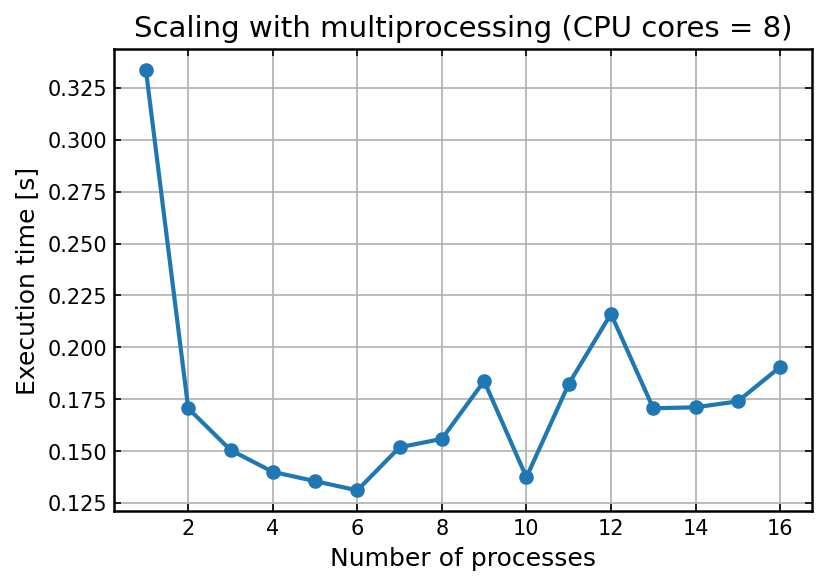

Number of processes | Execution time [s]
-----------------------------------------
                 1 | 0.333301
                 2 | 0.170701
                 3 | 0.150650
                 4 | 0.140150
                 5 | 0.135695
                 6 | 0.131245
                 7 | 0.151981
                 8 | 0.156010
                 9 | 0.183858
                10 | 0.137537
                11 | 0.182364
                12 | 0.216183
                13 | 0.170747
                14 | 0.171198
                15 | 0.174062
                16 | 0.190585

Interpretation of scaling:
The scaling is close to ideal for a small number of processes, where the execution time decreases almost linearly with the number of cores.
As the number of processes approaches the available CPU cores, the performance gain saturates.
For a larger number of processes, the execution time increases due to multiprocessing overhead and CPU contention, causing a clear deviation from perfect linear scaling.


In [158]:
import numpy as np
import multiprocessing as mp
import time
import os
import matplotlib.pyplot as plt


def heavy_computation(chunk):
    return np.sum(np.sqrt(chunk) * np.cos(chunk))

mp.set_start_method("fork", force=True)
mp.freeze_support()

N = 12000000
data = np.random.random(N)

n_cores = os.cpu_count()
max_processes = 2 * n_cores

processes_list = range(1, max_processes + 1)
execution_times = []

for n_proc in processes_list:
    chunks = np.array_split(data, n_proc)

    t0 = time.time()
    
    with mp.Pool(processes=n_proc) as pool:
        pool.map(heavy_computation, chunks)
    
    t1 = time.time()

    execution_times.append(t1 - t0)
    


plt.figure()
plt.plot(processes_list, execution_times, marker="o")
plt.xlabel("Number of processes")
plt.ylabel("Execution time [s]")
plt.title(f"Scaling with multiprocessing (CPU cores = {n_cores})")
plt.grid(True)
plt.show()

print("Number of processes | Execution time [s]")
print("-----------------------------------------")
for p, t in zip(processes_list, execution_times):
    print(f"{p:18d} | {t:.6f}")


    # Aggiungere interpretazione dello scaling
print("\nInterpretation of scaling:")
print("The scaling is close to ideal for a small number of processes, where the execution time decreases almost linearly with the number of cores.")
print("As the number of processes approaches the available CPU cores, the performance gain saturates.")
print("For a larger number of processes, the execution time increases due to multiprocessing overhead and CPU contention, causing a clear deviation from perfect linear scaling.")


# Lecture 8 

## Q1: I love pip 

- Take a piece of python code you wrote (for instance pick one of the exercises you've done for this class). 
- Turn it into a module
- Install it locally
- Deploy on pypi (only using the test-pypi server!)


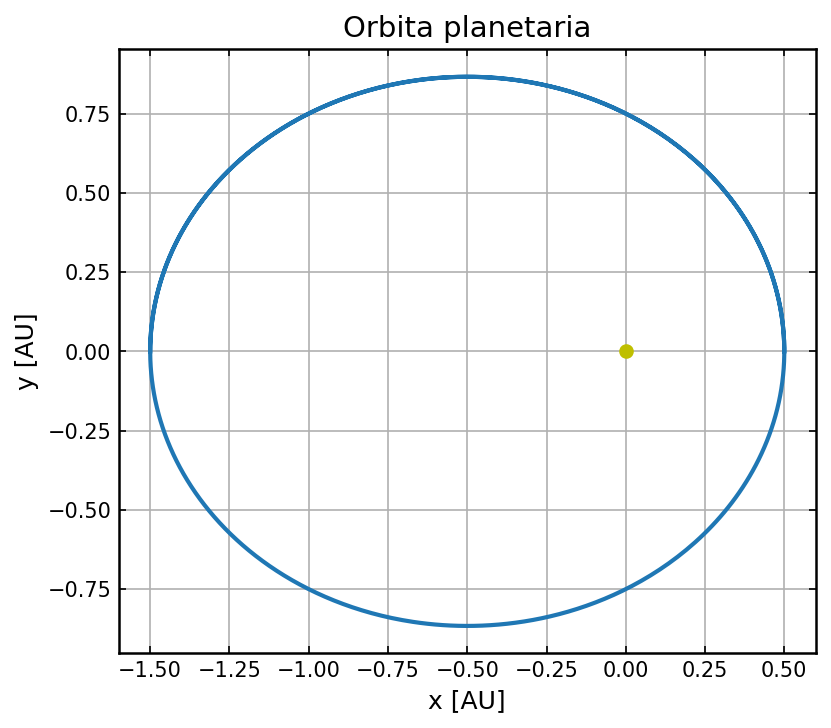

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.925e-06 ...  1.499e+00  1.500e+00]
        y: [[ 5.000e-01  5.000e-01 ... -1.500e+00 -1.500e+00]
            [ 0.000e+00  9.713e-05 ...  3.661e-03  1.253e-09]
            [ 0.000e+00 -1.409e-03 ... -1.771e-02 -7.067e-09]
            [ 1.088e+01  1.088e+01 ... -3.628e+00 -3.628e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 4520
     njev: 0
      nlu: 0

In [160]:
import orbita

orbita.orbita_planetaria(a=1.0, e=0.5)


## Q4: So slow

Pick a piece of your code that you dislike. It's sooooo slooooow. 
- Profile it.
- Find the bottleneck.
- Rewrite that bottleneck making a better use of numpy arrays, or jitting it with Numba.
- Enjoy your faster code


In [162]:
import time
import numpy as np
from numba import njit
import cProfile

N = 50000000  # abbastanza grande per far rallentare Python puro
data = np.random.rand(N)  # array NumPy
data_list = data.tolist()  # lista Python per il loop lento


def slow_sum_of_squares(lst):
    total = 0.0
    for x in lst:
        total += x**2
    return total

print("=== Profiling codice lento Python ===")
cProfile.run("slow_sum_of_squares(data_list)")

start = time.time()
result_slow = slow_sum_of_squares(data_list)
end = time.time()
print("\nSlow Python result:", result_slow)
print("Time (slow Python):", end - start, "seconds\n")


start = time.time()
result_numpy = np.sum(data ** 2)
end = time.time()
print("NumPy result:", result_numpy)
print("Time (NumPy):", end - start, "seconds\n")

=== Profiling codice lento Python ===
         555 function calls (550 primitive calls) in 3.061 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.029    0.029    0.029    0.029 2212738497.py:11(slow_sum_of_squares)
        2    0.000    0.000    0.000    0.000 <frozen abc>:121(__subclasscheck__)
        4    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1390(_handle_fromlist)
        1    0.738    0.738    2.787    2.787 <string>:1(<module>)
        4    0.000    0.000    0.000    0.000 __init__.py:183(dumps)
        2    0.000    0.000    0.048    0.024 asyncio.py:200(_handle_events)
        1    0.000    0.000    0.000    0.000 asyncio.py:210(call_at)
        4    0.000    0.000    0.000    0.000 attrsettr.py:42(__getattr__)
        4    0.000    0.000    0.000    0.000 attrsettr.py:65(_get_attr_opt)
        2    0.000    0.000    0.000    0.000 base_events.py:1895(_add_callback)
        3  